# Entrenamiento e iteración de hiperparámetros

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print("Device:", device)


Device: cpu


### 1. Preparación de Datos

In [2]:
df = pd.read_csv("housing.csv")

# Imputación de nulos (igual que en el EDA)
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

# One-Hot Encoding de la variable categórica (dtype=float para evitar columnas bool
# mezcladas con float, lo que rompe la conversión a tensores de PyTorch)
df_encoded = pd.get_dummies(df, columns=["ocean_proximity"], prefix="ocean", dtype=float)

# Separar features (X) y target (y)
X = df_encoded.drop(columns=["median_house_value"])
y = df_encoded["median_house_value"]

features_numericas = ["longitude", "latitude", "housing_median_age", "total_rooms",
                       "total_bedrooms", "population", "households", "median_income"]

print("Shape de X:", X.shape)
print("Columnas de X:", list(X.columns))


Shape de X: (20640, 13)
Columnas de X: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']


In [3]:
# 1) Separar TEST y dejarlo completamente aparte
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)

# 2) Del resto, separar VALIDATION (usado para tuning de hiperparámetros)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=SEED
)  # proporciones finales ~70% train / ~15% val / ~15% test

print(f"Train: {X_train.shape[0]} obs ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} obs ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} obs ({X_test.shape[0]/len(X)*100:.1f}%)")


Train: 14447 obs (70.0%)
Val:   3097 obs (15.0%)
Test:  3096 obs (15.0%)


In [4]:
scaler_X = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_numericas] = scaler_X.fit_transform(X_train[features_numericas])
X_val_scaled[features_numericas]   = scaler_X.transform(X_val[features_numericas])
X_test_scaled[features_numericas]  = scaler_X.transform(X_test[features_numericas])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

# Tensores de PyTorch
X_train_t = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled.values,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled.values,  dtype=torch.float32)

y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_t   = torch.tensor(y_val_scaled,   dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled,  dtype=torch.float32)

# Valores originales (en dólares) para el cálculo de métricas
y_val_orig  = y_val.values.reshape(-1, 1)
y_test_orig = y_test.values.reshape(-1, 1)

input_dim = X_train_t.shape[1]
print("input_dim:", input_dim)


input_dim: 13


### 2. Arquitectura MLP

In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation=nn.ReLU, dropout=0.0):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))  # capa de salida: regresión (1 valor)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


### 3. Función genérica de entrenamiento y evaluación

In [6]:
def build_optimizer(model, config):
    opt_name = config.get("optimizer", "adam")
    lr = config.get("lr", 1e-3)
    weight_decay = config.get("weight_decay", 0.0)

    if opt_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "sgd":
        momentum = config.get("momentum", 0.0)
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    elif opt_name == "rmsprop":
        return torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Optimizador no soportado: {opt_name}")


def train_model(config, X_train, y_train, X_val, y_val, seed=SEED):
    torch.manual_seed(seed)

    model = MLP(
        input_dim=X_train.shape[1],
        hidden_layers=config["hidden_layers"],
        activation=config.get("activation", nn.ReLU),
        dropout=config.get("dropout", 0.0),
    ).to(device)

    optimizer = build_optimizer(model, config)
    criterion = nn.MSELoss()
    l1_lambda = config.get("l1_lambda", 0.0)

    train_ds = TensorDataset(X_train, y_train)
    g = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True, generator=g)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(config["epochs"]):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            mse_loss = criterion(pred, yb)

            total_loss = mse_loss
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                total_loss = total_loss + l1_lambda * l1_norm

            total_loss.backward()
            optimizer.step()
            batch_losses.append(mse_loss.item())  # se registra el MSE puro, sin la penalización L1

        train_loss = float(np.mean(batch_losses))

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

    return model, history


def evaluate_model(model, X, y_orig, scaler_y):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X).numpy()
    pred_orig = scaler_y.inverse_transform(pred_scaled)

    mse = mean_squared_error(y_orig, pred_orig)
    mae = mean_absolute_error(y_orig, pred_orig)
    rmse = np.sqrt(mse)
    return {"MSE": mse, "MAE": mae, "RMSE": rmse}


### 4. Diseño de las 13 iteraciones 

In [7]:
configs = [
    dict(id="C1_baseline",        cambio="Baseline",
         hidden_layers=[64, 32], activation=nn.ReLU, optimizer="adam", lr=1e-3,
         batch_size=64, epochs=60),

    dict(id="C2_arch_pequena",    cambio="Arquitectura más pequeña",
         hidden_layers=[16], activation=nn.ReLU, optimizer="adam", lr=1e-3,
         batch_size=64, epochs=60),

    dict(id="C3_arch_grande",     cambio="Arquitectura más grande/profunda",
         hidden_layers=[128, 64, 32, 16], activation=nn.ReLU, optimizer="adam", lr=1e-3,
         batch_size=64, epochs=60),

    dict(id="C4_tanh",            cambio="Activación Tanh",
         hidden_layers=[64, 32], activation=nn.Tanh, optimizer="adam", lr=1e-3,
         batch_size=64, epochs=60),

    dict(id="C5_leakyrelu",       cambio="Activación LeakyReLU",
         hidden_layers=[64, 32], activation=nn.LeakyReLU, optimizer="adam", lr=1e-3,
         batch_size=64, epochs=60),

    dict(id="C6_sgd_momentum",    cambio="Optimizador SGD + momentum",
         hidden_layers=[64, 32], activation=nn.ReLU, optimizer="sgd", lr=1e-2, momentum=0.9,
         batch_size=64, epochs=60),

    dict(id="C7_rmsprop",         cambio="Optimizador RMSprop",
         hidden_layers=[64, 32], activation=nn.ReLU, optimizer="rmsprop", lr=1e-3,
         batch_size=64, epochs=60),

    dict(id="C8_adam_lr_alto",    cambio="lr de Adam más alto (0.01)",
         hidden_layers=[64, 32], activation=nn.ReLU, optimizer="adam", lr=1e-2,
         batch_size=64, epochs=60),

    dict(id="C9_batch_grande",    cambio="Batch size grande (256)",
         hidden_layers=[64, 32], activation=nn.ReLU, optimizer="adam", lr=1e-3,
         batch_size=256, epochs=60),

    dict(id="C10_batch_pequeno",  cambio="Batch size pequeño (16)",
         hidden_layers=[64, 32], activation=nn.ReLU, optimizer="adam", lr=1e-3,
         batch_size=16, epochs=60),

    dict(id="C11_dropout",        cambio="Arq. grande (C3) + Dropout 0.3",
         hidden_layers=[128, 64, 32, 16], activation=nn.ReLU, optimizer="adam", lr=1e-3,
         batch_size=64, epochs=60, dropout=0.3),

    dict(id="C12_l2",             cambio="Arq. grande (C3) + L2 (weight_decay=1e-3)",
         hidden_layers=[128, 64, 32, 16], activation=nn.ReLU, optimizer="adam", lr=1e-3,
         batch_size=64, epochs=60, weight_decay=1e-3),

    dict(id="C13_l1",             cambio="Arq. grande (C3) + L1 (l1_lambda=1e-4)",
         hidden_layers=[128, 64, 32, 16], activation=nn.ReLU, optimizer="adam", lr=1e-3,
         batch_size=64, epochs=60, l1_lambda=1e-4),
]

print(f"Total de configuraciones a entrenar: {len(configs)}")


Total de configuraciones a entrenar: 13


### 5. Entrenamiento de las 13 iteraciones

In [8]:
import time

trained_models = {}
histories = {}
results = []

t0 = time.time()
for cfg in configs:
    t_start = time.time()
    model, history = train_model(cfg, X_train_t, y_train_t, X_val_t, y_val_t)
    metrics_val = evaluate_model(model, X_val_t, y_val_orig, scaler_y)
    elapsed = time.time() - t_start

    trained_models[cfg["id"]] = model
    histories[cfg["id"]] = history

    results.append({
        "id": cfg["id"],
        "cambio": cfg["cambio"],
        "hidden_layers": cfg["hidden_layers"],
        "activation": cfg.get("activation", nn.ReLU).__name__,
        "optimizer": cfg.get("optimizer", "adam"),
        "lr": cfg.get("lr", 1e-3),
        "batch_size": cfg["batch_size"],
        "epochs": cfg["epochs"],
        "dropout": cfg.get("dropout", 0.0),
        "weight_decay": cfg.get("weight_decay", 0.0),
        "l1_lambda": cfg.get("l1_lambda", 0.0),
        "train_loss_final": history["train_loss"][-1],
        "val_loss_final": history["val_loss"][-1],
        "MSE_val": metrics_val["MSE"],
        "MAE_val": metrics_val["MAE"],
        "RMSE_val": metrics_val["RMSE"],
    })
    print(f"[{cfg['id']}] listo en {elapsed:.1f}s | RMSE_val = {metrics_val['RMSE']:.1f}")

print(f"\nTiempo total de entrenamiento: {time.time()-t0:.1f}s")


[C1_baseline] listo en 4.4s | RMSE_val = 52301.8
[C2_arch_pequena] listo en 3.2s | RMSE_val = 56882.8
[C3_arch_grande] listo en 5.6s | RMSE_val = 51449.8
[C4_tanh] listo en 4.5s | RMSE_val = 52687.3
[C5_leakyrelu] listo en 3.9s | RMSE_val = 52163.7
[C6_sgd_momentum] listo en 3.3s | RMSE_val = 51581.9
[C7_rmsprop] listo en 3.7s | RMSE_val = 51581.0
[C8_adam_lr_alto] listo en 3.6s | RMSE_val = 53097.2
[C9_batch_grande] listo en 2.0s | RMSE_val = 52571.2
[C10_batch_pequeno] listo en 9.4s | RMSE_val = 52093.3
[C11_dropout] listo en 5.2s | RMSE_val = 52449.1
[C12_l2] listo en 4.5s | RMSE_val = 51199.8
[C13_l1] listo en 5.6s | RMSE_val = 51647.9

Tiempo total de entrenamiento: 58.8s


In [9]:
results_df = pd.DataFrame(results).sort_values("RMSE_val").reset_index(drop=True)
results_df

,id,cambio,hidden_layers,activation,optimizer,lr,batch_size,epochs,dropout,weight_decay,l1_lambda,train_loss_final,val_loss_final,MSE_val,MAE_val,RMSE_val
0,C12_l2,Arq. grande (C3) + L2 (weight_decay=1e-3),"[128, 64, 32, 16]",ReLU,adam,0.001,64,60,0.0,0.001,0.0000,0.180561,0.196428,2.621423e+09,33791.404145,51199.836426
1,C3_arch_grande,Arquitectura más grande/profunda,"[128, 64, 32, 16]",ReLU,adam,0.001,64,60,0.0,0.000,0.0000,0.158062,0.198351,2.647084e+09,33668.854165,51449.821549
2,C7_rmsprop,Optimizador RMSprop,"[64, 32]",ReLU,rmsprop,0.001,64,60,0.0,0.000,0.0000,0.183525,0.199364,2.660603e+09,34515.237880,51581.030392
3,C6_sgd_momentum,Optimizador SGD + momentum,"[64, 32]",ReLU,sgd,0.010,64,60,0.0,0.000,0.0000,0.185488,0.199371,2.660697e+09,34960.391077,51581.944425
4,C13_l1,Arq. grande (C3) + L1 (l1_lambda=1e-4),"[128, 64, 32, 16]",ReLU,adam,0.001,64,60,0.0,0.000,0.0001,0.182774,0.199882,2.667510e+09,34129.989179,51647.947673
5,C10_batch_pequeno,Batch size pequeño (16),"[64, 32]",ReLU,adam,0.001,16,60,0.0,0.000,0.0000,0.174987,0.203343,2.713709e+09,34871.692150,52093.276212
6,C5_leakyrelu,Activación LeakyReLU,"[64, 32]",LeakyReLU,adam,0.001,64,60,0.0,0.000,0.0000,0.181773,0.203894,2.721056e+09,34907.372123,52163.742768
7,C1_baseline,Baseline,"[64, 32]",ReLU,adam,0.001,64,60,0.0,0.000,0.0000,0.185431,0.204975,2.735480e+09,34893.633007,52301.816885
8,C11_dropout,Arq. grande (C3) + Dropout 0.3,"[128, 64, 32, 16]",ReLU,adam,0.001,64,60,0.3,0.000,0.0000,0.265978,0.206131,2.750906e+09,36254.797290,52449.080365
9,C9_batch_grande,Batch size grande (256),"[64, 32]",ReLU,adam,0.001,256,60,0.0,0.000,0.0000,0.194782,0.207092,2.763733e+09,36218.828762,52571.215670


### 6. Curvas de pérdida de entrenamiento y validación

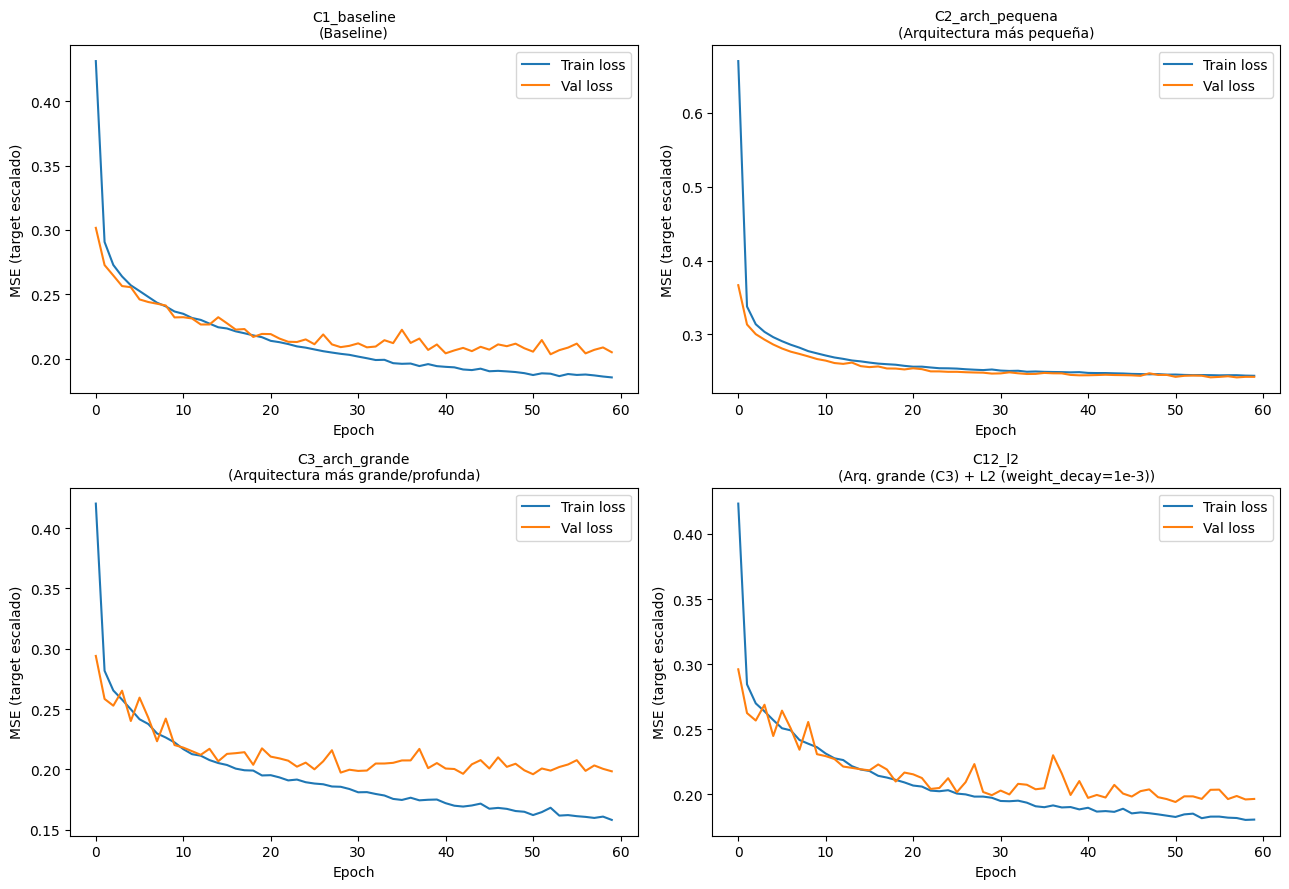

In [10]:
ids_a_graficar = ["C1_baseline", "C2_arch_pequena", "C3_arch_grande", "C12_l2"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, cid in zip(axes, ids_a_graficar):
    h = histories[cid]
    ax.plot(h["train_loss"], label="Train loss")
    ax.plot(h["val_loss"], label="Val loss")
    cambio = results_df.loc[results_df["id"] == cid, "cambio"].values[0]
    ax.set_title(f"{cid}\n({cambio})", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE (target escalado)")
    ax.legend()

plt.tight_layout()
plt.show()


### 7. Selección del mejor modelo según validación

In [11]:
best_row = results_df.iloc[0]
best_id = best_row["id"]
print("Mejor configuración según RMSE de validación:")
print(best_row[["id", "cambio", "hidden_layers", "activation", "optimizer", "lr",
                 "batch_size", "epochs", "dropout", "weight_decay", "l1_lambda",
                 "MSE_val", "MAE_val", "RMSE_val"]])


Mejor configuración según RMSE de validación:
id                                                  C12_l2
cambio           Arq. grande (C3) + L2 (weight_decay=1e-3)
hidden_layers                            [128, 64, 32, 16]
activation                                            ReLU
optimizer                                             adam
lr                                                   0.001
batch_size                                              64
epochs                                                  60
dropout                                                0.0
weight_decay                                         0.001
l1_lambda                                              0.0
MSE_val                                  2621423250.090572
MAE_val                                       33791.404145
RMSE_val                                      51199.836426
Name: 0, dtype: object


### 8. Evaluación final sobre el conjunto de test

In [12]:
best_model = trained_models[best_id]
metrics_test = evaluate_model(best_model, X_test_t, y_test_orig, scaler_y)

print(f"Mejor configuración: {best_id}")
print("Métricas sobre el conjunto de TEST (evaluado una sola vez):")
for k, v in metrics_test.items():
    print(f"  {k}: {v:,.2f}")


Mejor configuración: C12_l2
Métricas sobre el conjunto de TEST (evaluado una sola vez):
  MSE: 2,741,540,371.23
  MAE: 35,115.78
  RMSE: 52,359.72
